# MSE802 Assessment 2 — Task 3: Quantum Tic-Tac-Toe

**Student:** ____________________  
**Runtime:** local Python 3.11 / Qiskit Aer

This notebook is a local-Jupyter adaptation of the course-supplied
`Quantum_Tic_Tac_Toe__AS2.ipynb`. The original Google Colab dependency is
removed; the completed game uses standard `ipywidgets` and testable project
code. See `SOURCE_NOTE.md` for the adaptation boundary.

## 1. Environment and local imports

The assessment starter installed packages inside Colab and used
`google.colab.widgets.Grid`. This version relies on the locked project
environment and portable `ipywidgets` components.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "Task_3_Quantum_Tic_Tac_Toe":
    ROOT = ROOT.parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import qiskit
from IPython.display import display
from qiskit_aer import AerSimulator

print(f"Qiskit version: {qiskit.__version__}")
print(f"Project root: {ROOT}")

Qiskit version: 2.5.1
Project root: D:\workshop\Codex\802-Quantum-Computing


## 2. Starter-code gap map

The supplied notebook left four gate operations, the eight winning triples,
and a reliable two-cell SWAP selection flow incomplete. Its board rendering
also depended on a Colab-only grid widget. The following sections complete
those items while keeping the starter's central idea: each move appends a
quantum gate and a one-shot measurement resolves the board.

## 3. Completed game model

The model lives in `mse802.tictactoe` so it can be tested independently of the
interface. Each square begins in

$$|+\rangle=\frac{|0\rangle+|1\rangle}{\sqrt{2}}.$$

The four moves append these gates:

- **O:** $R_Y(-\pi/2)|+\rangle=|0\rangle$;
- **X:** $R_Y(+\pi/2)|+\rangle=|1\rangle$;
- **Not:** Pauli-$X$, interchanging the $|0\rangle$ and $|1\rangle$
  amplitudes; and
- **SWAP:** exchanges the complete states of two selected qubits.

The labels O = measured 0 and X = measured 1 follow the supplied comments
“rotation toward $|0\rangle$” and “rotation toward $|1\rangle$”.

Recorded moves:
{'operation': 'O', 'cell': 0, 'other_cell': None}
{'operation': 'X', 'cell': 1, 'other_cell': None}
{'operation': 'Not', 'cell': 2, 'other_cell': None}
{'operation': 'SWAP', 'cell': 0, 'other_cell': 1}


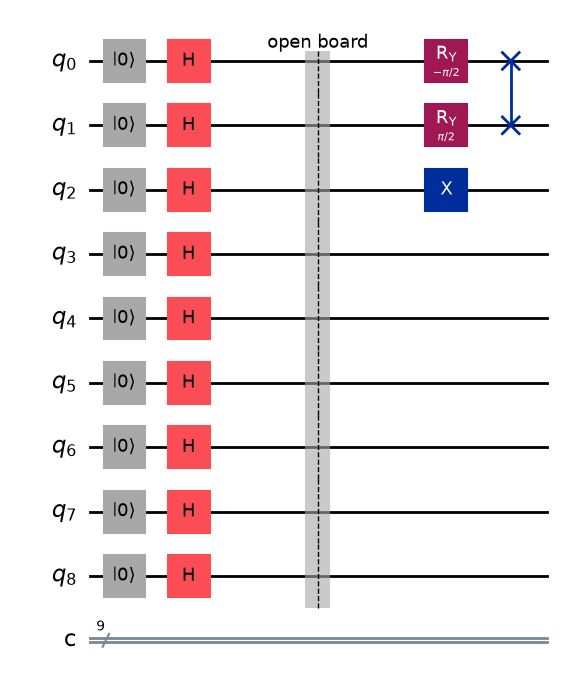

In [2]:
from mse802.tictactoe import Board

gate_demo = Board()
gate_demo.apply_move("O", 0)
gate_demo.apply_move("X", 1)
gate_demo.apply_move("Not", 2)
gate_demo.apply_move("SWAP", 0, 1)

print("Recorded moves:")
for move in gate_demo.move_log():
    print(move)
display(gate_demo.circuit.draw("mpl", fold=30))

## 4. Local interactive game

The native `ipywidgets` interface is added after the game model is complete.

## 5. Reproducible game evidence

Multiple deterministic and sampled games, circuit evidence, and outcome
analysis are added after the automated checks pass.